In [4]:
import pandas as pd

CDPR = pd.read_csv('CDPRusd.csv')
CDPR.set_index('date', inplace=True)
CDPR

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
date,,,,,,,,
2018-01-01,22.989877,22.989877,22.989877,22.989877,22.989877,0,0.0,0.0
2018-01-02,22.989877,22.989877,22.989877,22.989877,22.989877,0,0.0,0.0
2018-01-03,23.155780,23.700901,23.155780,23.226883,23.226883,212199,0.0,0.0
2018-01-04,23.463892,23.641649,23.049127,23.226883,23.226883,192525,0.0,0.0
2018-01-05,23.463894,23.558698,23.167633,23.463894,23.463894,120812,0.0,0.0
...,...,...,...,...,...,...,...,...
2023-10-25,26.049855,26.498989,25.825286,26.349277,26.349277,406034,0.0,0.0
2023-10-26,26.261946,26.910697,25.925095,26.586322,26.586322,336988,0.0,0.0
2023-10-27,26.598797,27.197645,26.498989,26.623749,26.623749,255269,0.0,0.0


In [5]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Load the data
CDPR = pd.read_csv('CDPRusd.csv')
CDPR.set_index('date', inplace=True)

# Select the features
features = ['Close', 'Volume']
data = CDPR[features].values

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Split the data into training and testing sets
train_size = int(len(scaled_data) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

# Create the training and testing datasets
def create_dataset(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback, 0])
    return np.array(X), np.array(y)

lookback = 60  # Number of previous time steps to use as input
X_train, y_train = create_dataset(train_data, lookback)
X_test, y_test = create_dataset(test_data, lookback)

# Reshape the input data to be 3-dimensional [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(features)))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], len(features)))

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], len(features))))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Make predictions on the test data
predictions = model.predict(X_test)

# Inverse transform the predictions and actual values


# Plot the actual vs predicted values



Epoch 1/10
36/36 [==============================] - 5s 33ms/step - loss: 0.0212
Epoch 2/10
36/36 [==============================] - 1s 31ms/step - loss: 0.0019
Epoch 3/10
36/36 [==============================] - 1s 31ms/step - loss: 0.0017
Epoch 4/10
36/36 [==============================] - 1s 32ms/step - loss: 0.0016
Epoch 5/10
36/36 [==============================] - 1s 37ms/step - loss: 0.0016
Epoch 6/10
36/36 [==============================] - 1s 36ms/step - loss: 0.0015
Epoch 7/10
36/36 [==============================] - 1s 37ms/step - loss: 0.0014
Epoch 8/10
36/36 [==============================] - 1s 40ms/step - loss: 0.0015
Epoch 9/10
36/36 [==============================] - 1s 33ms/step - loss: 0.0013
Epoch 10/10
8/8 [==============================] - 1s 10ms/step


In [3]:
# Assume predictions is the output from your LSTM model
predictions = model.predict(X_test)

# Create a dummy array for the 'Volume' feature
dummy_volume = np.zeros(predictions.shape)

# Combine predictions with dummy volume data
predictions_combined = np.hstack((predictions, dummy_volume))

# Inverse transform the predictions
predictions_inverse_transformed = scaler.inverse_transform(predictions_combined)

# Extract the 'Close' prices
final_predictions = predictions_inverse_transformed[:, 0]

# Similarly, if you want to inverse transform y_test
dummy_volume_test = np.zeros(y_test.shape).reshape(-1, 1)
test_data_combined = np.hstack((y_test.reshape(-1, 1), dummy_volume_test))
test_data_inverse_transformed = scaler.inverse_transform(test_data_combined)
final_y_test = test_data_inverse_transformed[:, 0]
final_y_test

8/8 [==============================] - 0s 16ms/step


array([36.35621154, 35.90064472, 34.48442562, 34.15265537, 34.3160638 ,
       35.00436742, 34.6626904 , 34.29625787, 32.5532181 , 32.42942153,
       30.59725318, 31.52324127, 31.64208636, 32.37495332, 31.81539776,
       31.31526569, 32.52845879, 33.3058967 , 33.92487196, 35.30642878,
       32.16202245, 32.84042311, 31.87482126, 31.69160309, 32.21154489,
       31.46877116, 32.01347037, 31.45391671, 31.11719308, 31.90453205,
       32.09765128, 32.02337334, 31.93919243, 31.56780842, 32.82061718,
       33.11277557, 34.20712358, 33.61290383, 32.17192923, 32.71662654,
       31.89462909, 32.03822969, 32.99888196, 32.80576083, 32.81071422,
       33.59805129, 33.15734082, 32.56312488, 33.34055898, 33.15238743,
       32.88003877, 34.49433239, 34.23683628, 36.09376585, 36.34630858,
       35.29652201, 34.97960811, 35.08359495, 35.02912293, 34.32596677,
       34.39033794, 33.23656834, 34.26654517, 34.54384721, 33.62776399,
       33.75650633, 32.48884693, 32.66711171, 33.30094332, 32.06

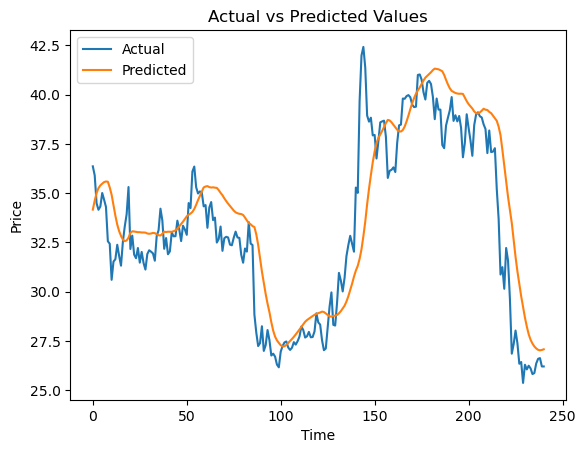

In [28]:
import matplotlib.pyplot as plt

# Plot the actual vs predicted values
plt.plot(final_y_test, label='Actual')
plt.plot(final_predictions, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()



In [6]:
# Save the model
model.save('model.h5')


/Users/liammartin/anaconda3/envs/statpack/lib/python3.11/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
